1) How to model a scientific experiment that includes an underlying relationship with both intrinsic randomness and experimental uncertainty.

2) Determine the significance of a measurement that deviates from the intrinsic randomness expected from an experiment.

3) Program Python functions to compute mathematical models and simulate experimental noise.

4) Plot models and data on the same graph using a Jupyter notebook, and provide a graphical representation of the statistical significance of an experimental event.

5) Develop code collaboratively using a standard development platform (GitHub).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import ascii
from scipy import optimize

1.035987083167414 0.017998660473206328 -3.5717397111188203 2.53967353734032


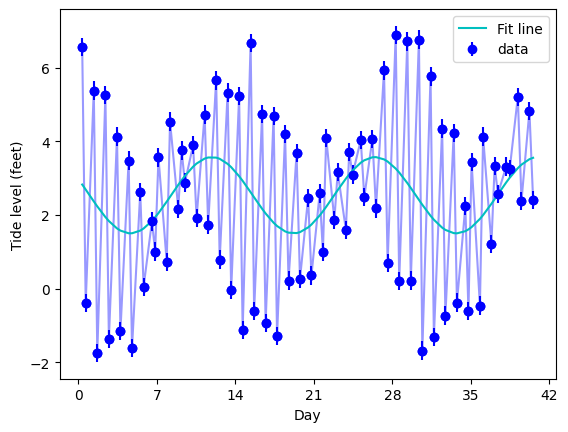

In [6]:
data = Table.read("ASTR19_F25_group_project_data.txt", format="ascii")
data['col4'] = [8.11666666666667, 15.6166666666667, 8.91666666666667, 16.4166666666667, 9.75, 17.2333333333333, 10.5833333333333, 18, 11.4666666666667, 18.7666666666667, 12.3666666666667, 19.5166666666667, 13.4, 20.2666666666667, 3.36666666666667, 21.0166666666667, 4.11666666666667, 21.7666666666667, 4.83333333333333, 11.9666666666667, 5.51666666666667, 12.9333333333333, 6.13333333333333, 13.75, 6.78333333333333, 14.4166666666667, 7.36666666666667, 15, 7.98333333333333, 15.5666666666667, 8.56666666666667, 16.1333333333333, 9.16666666666667, 16.6833333333333, 9.75, 17.2, 10.35, 17.75, 10.95, 18.25, 11.6333333333333, 18.8, 12.4166666666667, 19.3333333333333, 2.36666666666667, 19.8666666666667, 2.96666666666667, 20.5, 3.61666666666667, 10.7333333333333, 4.38333333333333, 11.9166666666667, 5.25, 12.95, 6.15, 13.8333333333333, 7.08333333333333, 14.65, 7.96666666666667, 15.45, 8.83333333333333, 16.1666666666667, 9.66666666666667, 16.8666666666667, 10.5, 17.5666666666667, 11.3166666666667, 18.2, 12.1666666666667, 18.8166666666667, 1.53333333333333, 19.4, 2.21666666666667, 20, 2.9, 9.9, 3.65, 11.25, 4.48333333333333, 12.3666666666667, 5.35, 13.2333333333333]

fig = plt.figure()
ax = fig.add_subplot(111)

x = ((data['col1'] - 1)*24) + data['col4']
y = data['col3']

ax.plot(x, y, 'bo')
ax.errorbar(x, y, yerr=0.25, fmt='bo', label='data')
ax.plot(x, y, 'b-', alpha=0.4)



def f_line(x, a, b, c, d):
    return a * np.sin(b*x + c) + d

#perform fit
params, params_cov = optimize.curve_fit(f_line, x, y, sigma=0.25, p0=[1, 0.012, 0, 2])

a_fit = params[0]
b_fit = params[1]
c_fit = params[2]
d_fit = params[3]

print(a_fit, b_fit, c_fit, d_fit)

y_fit = a_fit * np.sin(b_fit * x + c_fit) + d_fit

ax.plot(x, y_fit, 'c-', label='Fit line')

ax.set_xticks(np.linspace(0, 1008, 7), labels=('0', '7', '14', '21', '28', '35', '42'))
ax.set_xlabel('Day')
ax.set_ylabel('Tide level (feet)')

ax.legend()

Text(0, 0.5, 'Difference between data points and fit line')

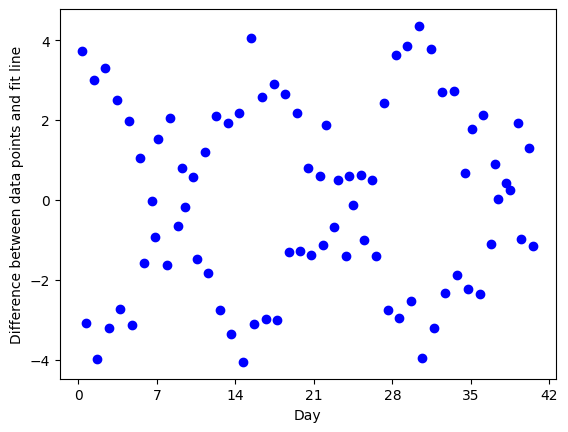

In [7]:
y2 = data['col3'] - y_fit   #tide level -best fit line

plt.plot(x, y2, 'bo')

plt.xticks(np.linspace(0, 1008, 7), labels=('0', '7', '14', '21', '28', '35', '42'))
plt.xlabel('Day')
plt.ylabel('Difference between data points and fit line')

2.270367047425246
2.2565607747265375


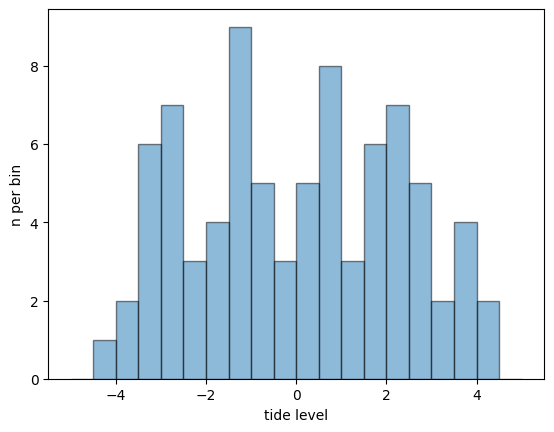

In [8]:
std = np.std(y2) #Standard deviation of values in above graph
print(std)

#estimating the intrinsic scatter
insc = (pow(std, 2) - pow(0.25, 2)) ** 0.5
print(insc)

width = 0.5
histmin = np.floor(min(y2))
histmax = np.ceil(max(y2)) + width
bins = np.arange(histmin, histmax, width)
plt.hist(y2, bins=bins, alpha=0.5, edgecolor="black")
plt.xlabel("tide level")
plt.ylabel("n per bin")
plt.savefig("tidalHistogram.pdf")

(array([0., 1., 2., 6., 7., 3., 4., 9., 5., 3., 5., 8., 3., 6., 7., 5., 2.,
        4., 2., 0.]),
 array([-5. , -4.5, -4. , -3.5, -3. , -2.5, -2. , -1.5, -1. , -0.5,  0. ,
         0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ]),
 <BarContainer object of 20 artists>)

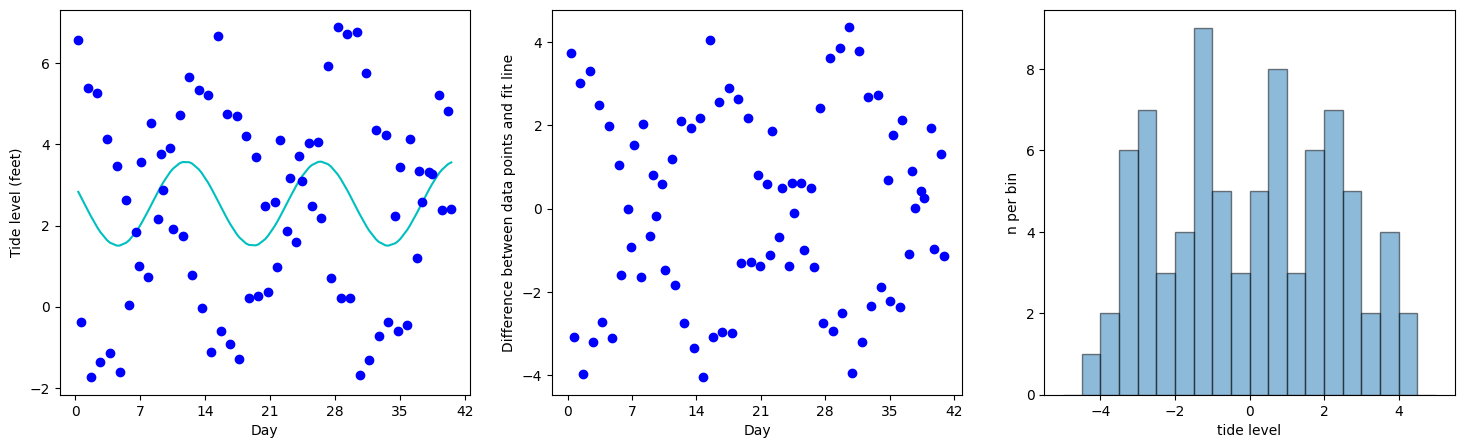

In [40]:
#Putting the two graphs together?

fig, axs = plt.subplots(1, 3, figsize=(18, 5))


axs[0].plot(x, y_fit, 'c-', label='Fit line')
axs[0].plot(x, y, 'bo', label='data')
axs[0].set_xticks(np.linspace(0, 1008, 7))
axs[0].set_xticklabels(['0', '7', '14', '21', '28', '35', '42'])
axs[0].set_ylabel("Tide level (feet)")
axs[0].set_xlabel("Day")
axs[0].plot(a_fit = params[0])
axs[0].plot(b_fit = params[1])
axs[0].plot(c_fit = params[2])
axs[0].plot(d_fit = params[3])

axs[1].plot(x, y2, 'bo')
axs[1].set_xticks(np.linspace(0, 1000, 7))
axs[1].set_xticklabels(['0', '7', '14', '21', '28', '35', '42'])
axs[1].set_xlabel("Day")
axs[1].set_ylabel("Difference between data points and fit line")

axs[2].plot(std = np.std(y2))
axs[2].plot(insc = (pow(std, 2) - pow(0.25, 2)) ** 0.5)
axs[2].set_xlabel("tide level")
axs[2].set_ylabel("n per bin")
width = 0.5
histmin = np.floor(min(y2))
histmax = np.ceil(max(y2)) + width
bins = np.arange(histmin, histmax, width)
plt.hist(y2, bins=bins, alpha=0.5, edgecolor="black")